In [1]:
# SQL Injection Detection - Model Training & Evaluation
# This notebook trains and evaluates ML models for SQL injection detection

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print("🚀 SQL Injection Detection - Model Training & Evaluation")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Load and Split Dataset
print("Step 1: Loading dataset...")

# Load the feature dataset
df = pd.read_csv(r"C:\Users\vishal\Desktop\WEBSCAN_PRO\data\feature_dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display basic info
print("\nDataset Info:")
print(df.info())
print(f"\nTarget distribution:\n{df['is_malicious'].value_counts()}")

🚀 SQL Injection Detection - Model Training & Evaluation
Step 1: Loading dataset...
Dataset shape: (28, 12)
Columns: ['url', 'response_time', 'html_content_length', 'error_message_flag', 'status_group', 'is_malicious', 'response_time_normalized', 'content_length_delta', 'payload_length', 'has_special_chars', 'has_sql_keywords', 'payload_complexity']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   url                       28 non-null     object 
 1   response_time             28 non-null     float64
 2   html_content_length       28 non-null     float64
 3   error_message_flag        28 non-null     int64  
 4   status_group              28 non-null     int64  
 5   is_malicious              28 non-null     int64  
 6   response_time_normalized  28 non-null     float64
 7   content_length_delta      28 no

In [5]:
## Prepare Features and Target
# Define features (X) and target (y)
feature_columns = ['response_time', 'html_content_length', 'error_message_flag', 'status_group']
X = df[feature_columns]
y = df['is_malicious']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

## Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)


Features shape: (28, 4)
Target shape: (28,)


In [6]:
print(f"\nData split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

## Step 2: Train Models
print("\nStep 2: Training models...")


Data split completed:
Training set: 22 samples
Testing set: 6 samples

Step 2: Training models...


In [7]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

Training Decision Tree...


DecisionTreeClassifier(random_state=42)

In [8]:
# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    max_depth=10
)
rf_model.fit(X_train, y_train)

print("Model training completed!")


Training Random Forest...
Model training completed!


In [9]:
## Step 3: Evaluate Model Performance
print("\nStep 3: Evaluating models...")

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics"""
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{model_name.upper()} Performance:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))


Step 3: Evaluating models...


🚀 SQL Injection Detection - Model Training & Evaluation
Step 1: Loading dataset...
Dataset shape: (28, 12)
Columns: ['url', 'response_time', 'html_content_length', 'error_message_flag', 'status_group', 'is_malicious', 'response_time_normalized', 'content_length_delta', 'payload_length', 'has_special_chars', 'has_sql_keywords', 'payload_complexity']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   url                       28 non-null     object 
 1   response_time             28 non-null     float64
 2   html_content_length       28 non-null     float64
 3   error_message_flag        28 non-null     int64  
 4   status_group              28 non-null     int64  
 5   is_malicious              28 non-null     int64  
 6   response_time_normalized  28 non-null     float64
 7   content_length_delta      28 no

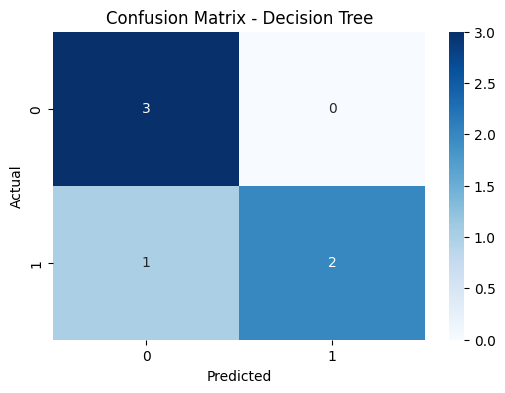


RANDOM FOREST Performance:
Accuracy:  0.8333
Precision: 1.0000
Recall:    0.6667
F1-Score:  0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



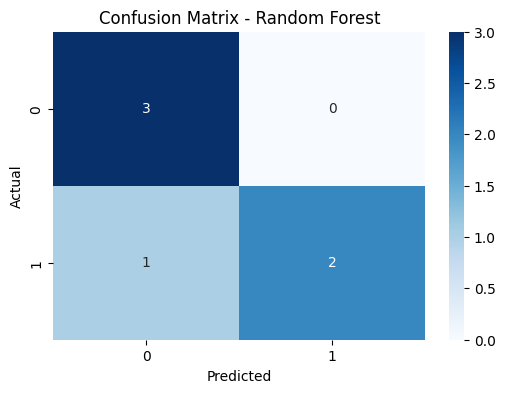


Step 4: Comparing models and selecting the best...

Model Comparison:
           Decision Tree  Random Forest
Accuracy          0.8333         0.8333
Precision         1.0000         1.0000
Recall            0.6667         0.6667
F1-Score          0.8000         0.8000

🎯 Best Model: Random Forest (F1-Score: 0.8000)

Step 5: Saving models and generating reports...
Models saved successfully!


In [12]:
# projects/sql_injection/notebooks/model_training_evaluation.ipynb

# SQL Injection Detection - Model Training & Evaluation
# This notebook trains and evaluates ML models for SQL injection detection

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 SQL Injection Detection - Model Training & Evaluation")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Load and Split Dataset
print("Step 1: Loading dataset...")

# Load the feature dataset
df = pd.read_csv('../data/feature_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display basic info
print("\nDataset Info:")
print(df.info())
print(f"\nTarget distribution:\n{df['is_malicious'].value_counts()}")

## Prepare Features and Target
# Define features (X) and target (y)
feature_columns = ['response_time', 'html_content_length', 'error_message_flag', 'status_group']
X = df[feature_columns]
y = df['is_malicious']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

## Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nData split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

## Step 2: Train Models
print("\nStep 2: Training models...")

# Train Decision Tree
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    max_depth=10
)
rf_model.fit(X_train, y_train)

print("Model training completed!")

## Step 3: Evaluate Model Performance
print("\nStep 3: Evaluating models...")

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics"""
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{model_name.upper()} Performance:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': cm
    }

# Evaluate both models
dt_metrics = evaluate_model(dt_model, X_test, y_test, 'Decision Tree')
rf_metrics = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

## Step 4: Compare and Select Best Model
print("\nStep 4: Comparing models and selecting the best...")

metrics_df = pd.DataFrame({
    'Decision Tree': [
        dt_metrics['accuracy'],
        dt_metrics['precision'], 
        dt_metrics['recall'],
        dt_metrics['f1_score']
    ],
    'Random Forest': [
        rf_metrics['accuracy'],
        rf_metrics['precision'],
        rf_metrics['recall'],
        rf_metrics['f1_score']
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("\nModel Comparison:")
print(metrics_df.round(4))

# Select best model based on F1-score
if dt_metrics['f1_score'] > rf_metrics['f1_score']:
    best_model = dt_model
    best_model_name = 'decision_tree'
    best_metrics = dt_metrics
    print(f"\n🎯 Best Model: Decision Tree (F1-Score: {dt_metrics['f1_score']:.4f})")
else:
    best_model = rf_model
    best_model_name = 'random_forest'
    best_metrics = rf_metrics
    print(f"\n🎯 Best Model: Random Forest (F1-Score: {rf_metrics['f1_score']:.4f})")

## Step 5: Save Model & Evaluation Report
print("\nStep 5: Saving models and generating reports...")

# Create directories if they don't exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../docs', exist_ok=True)

# Save models
with open('../models/decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Models saved successfully!")
